In [13]:
import time

import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt

from firm3d.field.boozermagneticfield import (
    BoozerRadialInterpolant,
    InterpolatedBoozerField,
)
from firm3d.field.trajectory_helpers import TrappedPoincare
from firm3d.util.constants import (
    ALPHA_PARTICLE_CHARGE,
    ALPHA_PARTICLE_MASS,
    FUSION_ALPHA_PARTICLE_ENERGY,
)
from firm3d.util.functions import proc0_print, setup_logging
from firm3d.util.mpi import comm_size, comm_world, verbose

# Can comment out these inputs below if call_DESC==False
from desc.ResonanceOpt.TRObj_func import TrappedResonanceObj
import desc.io
from desc.backend import set_device
set_device("cpu")
import jax.numpy as jnp

In [31]:
#######################
# COMMON USER INPUTS #
# firm3d setup
boozmn_filename = "../inputs/boozmn_equil_G1600_DESC_fixed.nc" # make sure this matches the DESC input
neta_poinc = 7  # Number of eta initial conditions for poincare
ns_poinc = 50  # Number of s initial conditions for poincare
Nmaps = 1000  # Number of Poincare return maps to compute
modBin = 6.05 # T
tmax = 1e-2

# DESC setup
eq = desc.io.load("../inputs/equil_Helios_E0092_DESC_fixed.h5") # make sure this matches the firm3d input
rhos_desc = (np.linspace(0.1,0.9,50))**(1/2) # rho = sqrt(s)
alphas_desc = np.linspace(0,2*np.pi,3)
KE_frac_desc = np.array([0.0001])
N=0 # QA
#######################

In [32]:
# Additional setup

Ekin = FUSION_ALPHA_PARTICLE_ENERGY * KE_frac_desc[0]
charge = ALPHA_PARTICLE_CHARGE
mass = ALPHA_PARTICLE_MASS

resolution = 48  # Resolution for field interpolation
ns_interp = resolution  # number of radial grid points for interpolation
ntheta_interp = resolution  # number of poloidal grid points for interpolation
nzeta_interp = resolution  # number of toroidal grid points for interpolation
order = 3  # order for interpolation
tol = 1e-8  # Tolerance for ODE solver
s_mirror = 0.5  # flux surface for mirroring
theta_mirror = np.pi / 2  # poloidal angle for mirroring
zeta_mirror = 0
helicity_M = 1  # helicity of field strength contours
helicity_N = N # =0 for QA
degree = 3  # Degree for Lagrange interpolation


# Setup logging to redirect output to file
#setup_logging(f"stdout_trapped_map_{resolution}_{comm_size}.txt")

In [27]:
# field initialization
time1 = time.time()

bri = BoozerRadialInterpolant(boozmn_filename, order, no_K=True, comm=comm_world)
# bri = BoozerRadialInterpolant(boozmn_filename, order, no_K=True, comm=comm_world, helicity_N=helicity_N, helicity_M=helicity_M) # specify helicities to filter QS-breaking modes

field = InterpolatedBoozerField(
    bri,
    degree,
    ns_interp=ns_interp,
    ntheta_interp=ntheta_interp,
    nzeta_interp=nzeta_interp,
)

time2 = time.time()
proc0_print("BRI and IBF time: ", time2 - time1)

BRI and IBF time:  225.86959528923035


In [33]:
# Trapped Map particle tracing
time1 = time.time()

poinc = TrappedPoincare(
    field,
    helicity_M,
    helicity_N,
    s_mirror,
    theta_mirror,
    zeta_mirror,
    mass,
    charge,
    Ekin,
    modBin=modBin,
    ns_poinc=ns_poinc,
    neta_poinc=neta_poinc,
    Nmaps=Nmaps,
    comm=comm_world,
    solver_options={"reltol": tol, "abstol": tol, "axis": 0},
    tmax=tmax,
)

time2 = time.time()
proc0_print("poincare time: ", time2 - time1)

Inverse Pitch =  6.05
poincare time:  1132.8519532680511


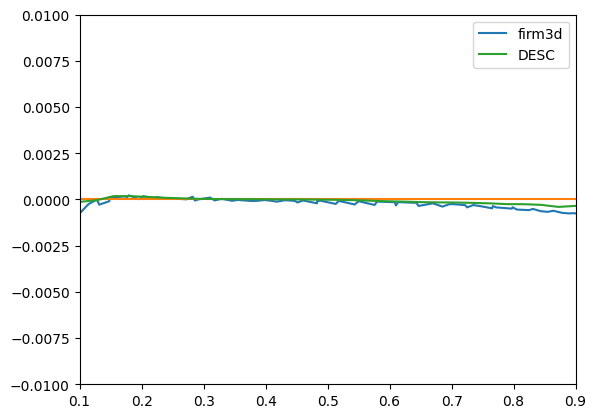

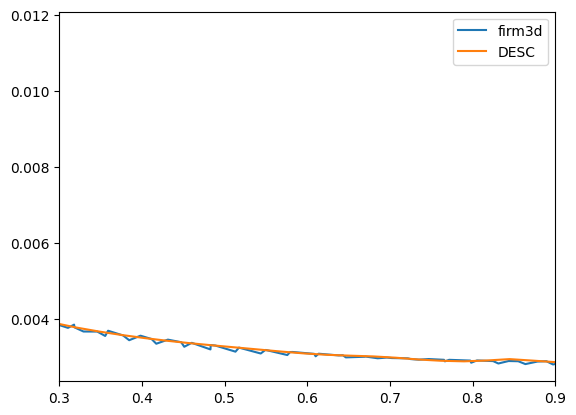

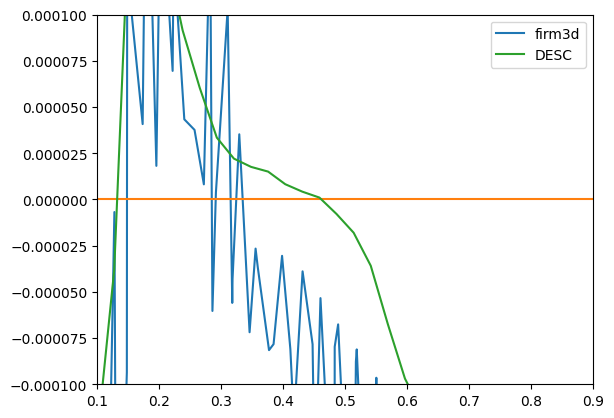

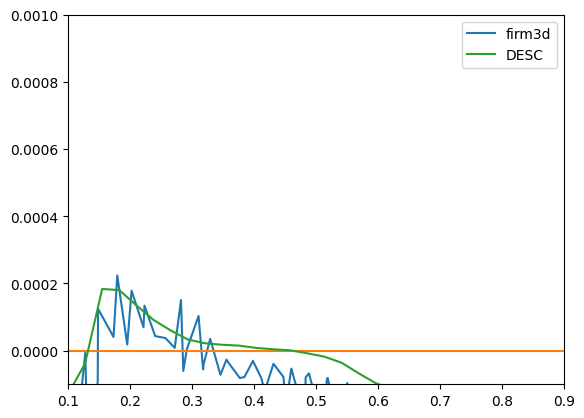

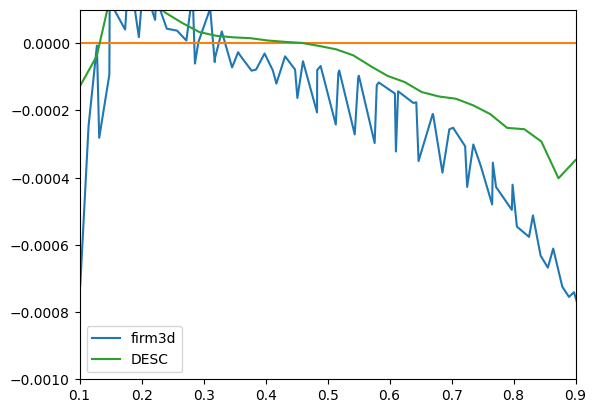

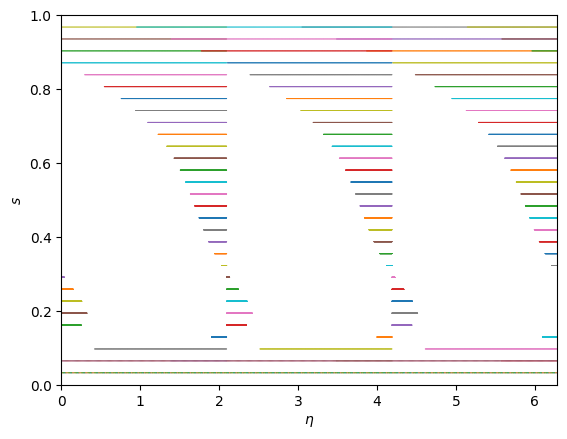

In [18]:
# Saving Poincare plot for testing
import pickle
fig,ax = plt.subplots()
ax = poinc.plot_poincare(ax=ax)
pickle.dump(fig, open("testingKE0001noQSbreak.pkl", "wb"))

In [41]:
# Frequency computation
Omega_eta_prof, Omega_b_prof, s_prof = poinc.compute_frequencies()
omega_eta = Omega_eta_prof / Omega_b_prof
plt.figure()
plt.plot(s_prof,omega_eta,label="firm3d")
plt.plot(s_prof,np.zeros(len(s_prof)))
omega_arr_DESC = np.loadtxt('freq_DESC.txt')
plt.plot(np.linspace(0.1,0.9,len(omega_arr_DESC)),-omega_arr_DESC,label='DESC')
plt.legend()
plt.xlim([0.1,0.9])
plt.ylim([-0.001,0.01])
plt.savefig('freq.png')

In [20]:
tau_b_firm3d = (Omega_b_prof / (2 * np.pi) )**(-1)
plt.figure()
plt.plot(s_prof,tau_b_firm3d,label="firm3d")
# plt.plot(s_prof,np.zeros(len(s_prof)))
tau_arr_DESC = np.loadtxt('tau_DESC.txt')
plt.plot(np.linspace(0.1,0.9,len(tau_arr_DESC)),tau_arr_DESC,label='DESC')
plt.legend()
plt.xlim([0.3,0.9])
# plt.ylim([-0.1,0.1])
plt.savefig('tau.png')


In [39]:
# Run or get DESC objective function
import os
if os.path.exists('obj_DESC.txt'):
    obj_val = np.loadtxt('obj_DESC.txt')
    s_obj = np.linspace(0.1,0.9,len(obj_val))
else:
    pitch_invs_desc = jnp.array([modBin])
    out = TrappedResonanceObj(eq,rhos_desc,pitch_invs_desc,KE_frac_desc,alphas_desc,N)
    obj_val = out['obj'][:,0,0] # Only look at rho, for one pitch, for one energy
    s_obj = np.linspace(0.1,0.9,len(obj_val))

In [40]:
# Poincare plotting overlaid with DESC objective function
fig, ax = plt.subplots()
ax = poinc.plot_poincare(ax=ax)

Y = s_obj
X = np.linspace(0,2*np.pi,5)
Z = np.transpose(np.tile(obj_val, (5, 1)))
cs = ax.contourf(X,Y,Z,cmap='Blues')
fig.colorbar(cs, ax=ax)

ax = poinc.plot_poincare(ax=ax)
ax.figure.savefig('poincare_objective_overlay.png')

In [ ]:
# Run after kernel restart to get Poincare plot back
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')  # Don't use interactive backend
import matplotlib.pyplot
import pickle
fig = pickle.load(open("testing.pkl", "rb"))

# now overplot DESC info
Y = s_obj
X = np.linspace(0,2*np.pi,5)
Z = np.transpose(np.tile(obj_val, (5, 1)))
ax = fig.axes[0]
cs = ax.contourf(X,Y,Z,cmap='Blues')
fig.colorbar(cs, ax=ax)
# fig.show()
# fig.savefig('testing.png')

In [ ]:
# Objective function testing
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')  # Don't use interactive backend
import matplotlib.pyplot

plt.figure(2)
plt.plot(rhos_desc**2,out['obj_bump'][:,0,0],label='bump value') # summed over all resonances
plt.xlim([0.1,0.7])
plt.legend()

plt.figure(3)
plt.plot(rhos_desc**2,out['psi_da'][:,0,0]**2,label='Normalized abs(gradpsi value)')
plt.legend()

ress = out['res'][0,0,0,:]
plt.figure(4)
plt.plot(rhos_desc**2,out['omega'][:,0,0,0],'o',label="omega zeta")
for res in ress:
    plt.plot(rhos_desc**2,np.ones(len(rhos_desc))*res,'--')
plt.ylim([-1,1])
plt.legend()

plt.figure(5)
plt.plot(rhos_desc**2,out['obj'][:,0,0],label="objective function")
plt.legend()

# import pickle
# fig,ax = plt.subplots()
# pickle.load(open("testing.pkl", "rb"))
# Y = s_obj
# X = np.linspace(0,2*np.pi,5)
# Z = np.transpose(np.tile(obj_val, (5, 1)))
# cs = ax.contourf(X,Y,Z,cmap='Blues')
# fig.colorbar(cs,ax=ax)
